# hFF Ratio Fit  —  global WLS in log space

Fits the 1-D `hFF_0_{iQ2}_{ixB}` histograms from a ratios ROOT file.  
Each histogram gives the π⁺/π⁻ ratio as a function of *z* for one (Q², xB) bin.  
The full (xB, Q², z) data cube is fit globally with the same factorised polynomial model used in `plotCorrections3D.ipynb`:

$$\ln R = P(\ln x_B,\,\ln Q^2) + \sum_{k=1}^{d_R}\left[\sum_{m=0}^{d_{ZQ}} r_{k,m}^{Q}\,t^k\,(\ln Q^2)^m + \sum_{n=1}^{d_{ZX}} r_{k,n}^{x}\,t^k\,(\ln x_B)^n\right]$$

where $t = (z - z_{\rm mid})/z_{\rm rng}$ is the normalised fragmentation variable.

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import math
from itertools import product as iproduct

FILE  = '../histograms/final_note/ratios_gen.root'
FILE2 = '../histograms/final_note/ratios_gen_rga.root'  # ← set second file here

# ── Fit degrees ───────────────────────────────────────────────────────────────
DEG_P  = 2   # total degree of 2D polynomial P(ln xB, ln Q²)
DEG_R  = 2   # degree of z polynomial
DEG_ZQ = 2   # degree of Q² modulation of each z^k term
DEG_ZX = 2   # degree of xB modulation of each z^k term

# Optional: exclude high-z rho-contaminated bins from the fit (set None to disable)
Z_FIT_MAX = 0.8

# ── Bin edges (must match cut_values.h) ──────────────────────────────────────
Q2_edges = np.linspace(2.0, 8.0, 13)   # 12 bins
xB_edges = np.linspace(0.1, 0.66, 15)  # 14 bins

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'font.family':       'sans-serif',
})

_cmap      = mcm.get_cmap('tab20')
N_COLORS   = 20
COLOR_LIST = [_cmap(i / N_COLORS) for i in range(N_COLORS)]
LABEL      = {'xB': r'$x_B$', 'Q2': r'$Q^2\;[\mathrm{GeV}^2]$', 'z': r'$z$'}

def panel_label(ax, text):
    ax.text(0.96, 0.96, text, transform=ax.transAxes, ha='right', va='top',
            fontsize=7.5, bbox=dict(boxstyle='round,pad=0.25', fc='white',
                                    ec='#aaaaaa', alpha=0.85))


/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_53357/2150976338.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap      = mcm.get_cmap('tab20')


In [299]:
# ── Load hFF histograms from a file into a 3D (xB, Q², z) array ──────────────

n_Q2 = len(Q2_edges) - 1
n_xB = len(xB_edges) - 1
Q2_centers = 0.5 * (Q2_edges[:-1] + Q2_edges[1:])
xB_centers = 0.5 * (xB_edges[:-1] + xB_edges[1:])

def load_hFF(filename):
    with uproot.open(filename) as f:
        _h0       = f['hRatio_0_1_1']
        z_edges_  = _h0.axis().edges()
        n_z_      = len(z_edges_) - 1
        z_centers_= 0.5 * (z_edges_[:-1] + z_edges_[1:])

        v_arr = np.full((n_xB, n_Q2, n_z_), np.nan)
        e_arr = np.full((n_xB, n_Q2, n_z_), np.nan)

        for iq in range(n_Q2):
            for ix in range(n_xB):
                key = f'hRatio_0_{iq+1}_{ix+1}'
                if key + ';1' not in f.keys():
                    continue
                h = f[key]
                v = h.values().copy()
                e = h.errors().copy()
                bad = ~(np.isfinite(v) & (v > 0) & np.isfinite(e) & (e > 0))
                v[bad] = np.nan
                e[bad] = np.nan
                v_arr[ix, iq, :] = v
                e_arr[ix, iq, :] = e

    return v_arr, e_arr, z_edges_, z_centers_


print('Loading FILE 1 ...')
vals1, errs1, z_edges, z_centers = load_hFF(FILE)
print('Loading FILE 2 ...')
vals2, errs2, z_edges2, z_centers2 = load_hFF(FILE2)

n_z   = len(z_edges) - 1
_Z_MID = 0.5 * (z_edges[0] + z_edges[-1])
_Z_RNG = 0.5 * (z_edges[-1] - z_edges[0])
z_fine = np.linspace(z_edges[0], z_edges[-1], 300)

# keep vals/errs pointing at file-1 data so existing plot cells still work
vals, errs = vals1, errs1

print(f'File 1 — finite entries: {np.sum(np.isfinite(vals1))}')
print(f'File 2 — finite entries: {np.sum(np.isfinite(vals2))}')
print(f'z range [{z_edges[0]:.2f}, {z_edges[-1]:.2f}],  mid={_Z_MID:.4f}, rng={_Z_RNG:.4f}')


Loading FILE 1 ...
Loading FILE 2 ...
File 1 — finite entries: 414
File 2 — finite entries: 410
z range [0.30, 1.00],  mid=0.6500, rng=0.3500


In [300]:
# ── Model definition and global WLS fit ──────────────────────────────────────

def _p_terms(d):
    return [(i, j) for i in range(d + 1) for j in range(d + 1 - i)]

def _build_features(z, ln_x, ln_q, pt, zq_terms, zx_terms):
    t    = (z - _Z_MID) / _Z_RNG
    cols = [ln_x**i * ln_q**j for (i, j) in pt]
    cols += [t**k * ln_q**m   for (k, m) in zq_terms]
    cols += [t**k * ln_x**n   for (k, n) in zx_terms]
    return np.column_stack(cols)


class Predictor:
    def __init__(self, theta, cov, pt, zq_terms, zx_terms):
        self.theta = theta; self.cov = cov
        self._pt = pt; self._zq = zq_terms; self._zx = zx_terms

    def _X(self, z, x, q):
        return _build_features(np.asarray(z).ravel(),
                               np.log(np.asarray(x).ravel()),
                               np.log(np.asarray(q).ravel()),
                               self._pt, self._zq, self._zx)

    def __call__(self, z, x, q):
        return np.exp(self._X(z, x, q) @ self.theta)

    def sigma_R(self, z, x, q):
        X   = self._X(z, x, q)
        var = np.einsum('ni,ij,nj->n', X, self.cov, X)
        return self(z, x, q) * np.sqrt(np.maximum(var, 0))


def fit_factorized(v, e, label='',
                   deg_p=DEG_P, deg_r=DEG_R, deg_zq=DEG_ZQ, deg_zx=DEG_ZX,
                   z_max=Z_FIT_MAX):
    pt       = _p_terms(deg_p)
    zq_terms = [(k, m) for k in range(1, deg_r + 1) for m in range(deg_zq + 1)]
    zx_terms = [(k, n) for k in range(1, deg_r + 1) for n in range(1, deg_zx + 1)]

    rows_z, rows_x, rows_q, rows_y, rows_w = [], [], [], [], []
    for ix, iq, iz in iproduct(range(n_xB), range(n_Q2), range(n_z)):
        if z_max is not None and z_centers[iz] >= z_max:
            continue
        vi, ei = v[ix, iq, iz], e[ix, iq, iz]
        if not (np.isfinite(vi) and np.isfinite(ei) and vi > 0 and ei > 0):
            continue
        rows_z.append(z_centers[iz]); rows_x.append(xB_centers[ix])
        rows_q.append(Q2_centers[iq]); rows_y.append(np.log(vi))
        rows_w.append((vi / ei) ** 2)

    z_arr = np.array(rows_z); x_arr = np.array(rows_x)
    q_arr = np.array(rows_q); y_arr = np.array(rows_y)
    w_arr = np.array(rows_w)

    X     = _build_features(z_arr, np.log(x_arr), np.log(q_arr), pt, zq_terms, zx_terms)
    XtW   = X.T * w_arr
    theta = np.linalg.solve(XtW @ X, XtW @ y_arr)
    cov   = np.linalg.inv(XtW @ X)
    n_par = len(theta)

    pred  = Predictor(theta, cov, pt, zq_terms, zx_terms)
    resid = y_arr - X @ theta
    ndof  = len(y_arr) - n_par
    chi2  = float(w_arr @ resid**2)
    print(f'  {label}deg_p={deg_p} deg_r={deg_r} deg_zq={deg_zq} deg_zx={deg_zx}  '
          f'n_par={n_par}  χ²/ndof={chi2/ndof:.3f}  ({len(y_arr)} bins, ndof={ndof})')
    return pred


print('Fitting FILE 1 ...')
pred_FF1 = fit_factorized(vals1, errs1, label='file1  ')
print('Fitting FILE 2 ...')
pred_FF2 = fit_factorized(vals2, errs2, label='file2  ')

# keep pred_FF pointing at file-1 so existing plot cells still work
pred_FF = pred_FF1


Fitting FILE 1 ...
  file1  deg_p=2 deg_r=2 deg_zq=2 deg_zx=2  n_par=16  χ²/ndof=6.823  (414 bins, ndof=398)
Fitting FILE 2 ...
  file2  deg_p=2 deg_r=2 deg_zq=2 deg_zx=2  n_par=16  χ²/ndof=3.804  (410 bins, ndof=394)


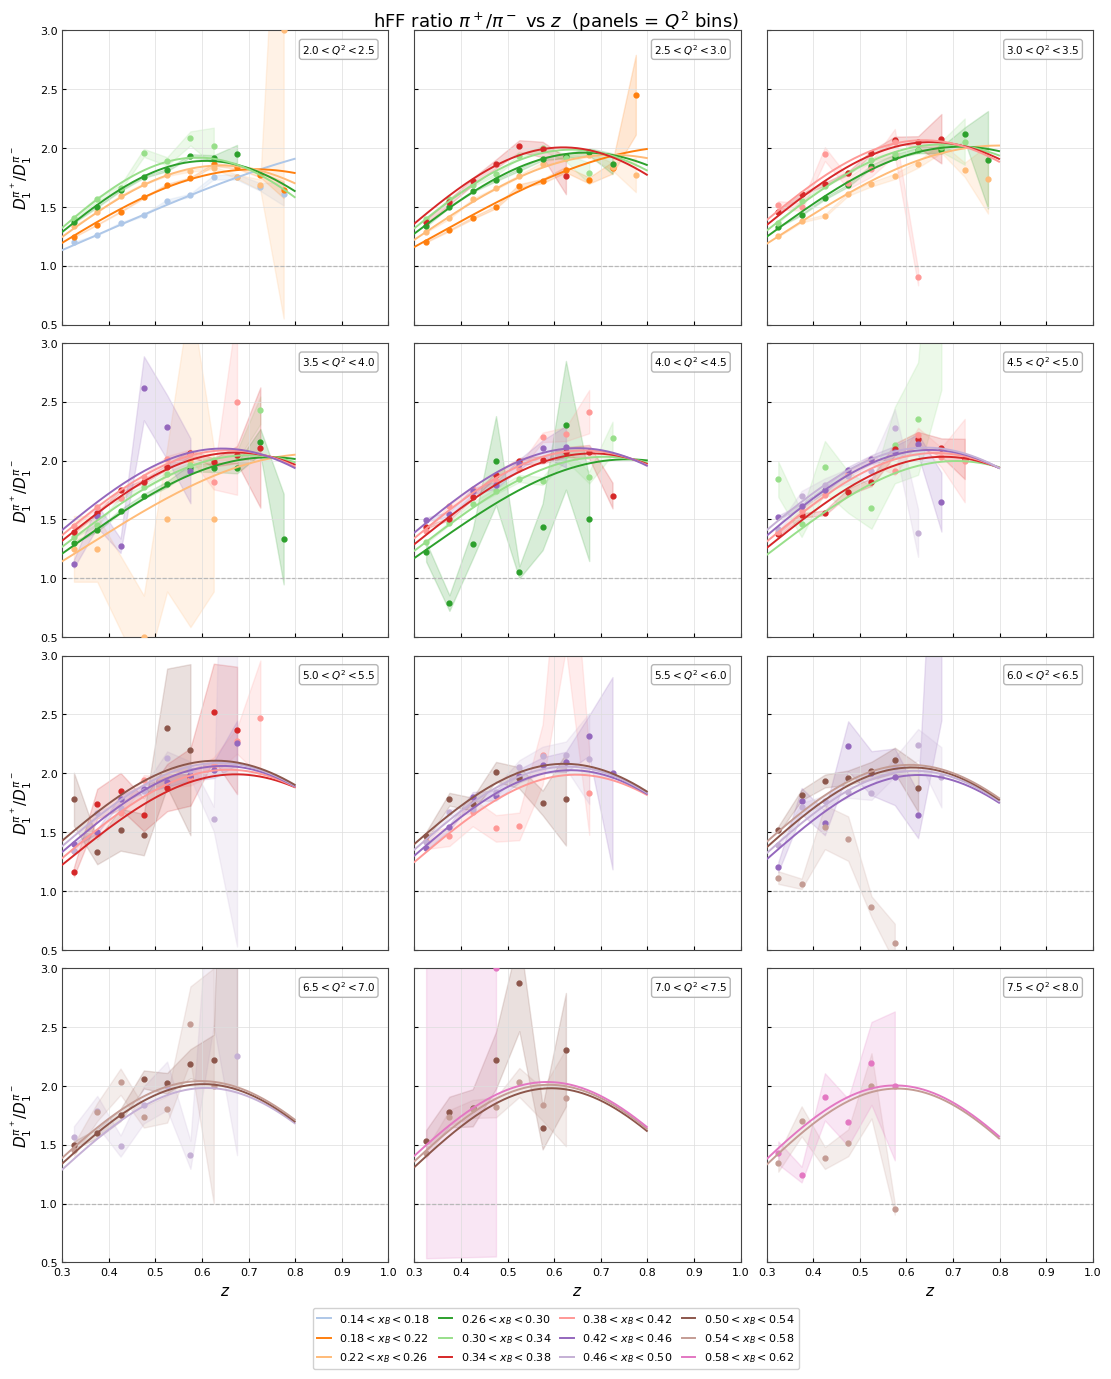

In [301]:
# ── hFF vs z  — panels = Q² bins, colours = xB bins ─────────────────────────

Y_LIM = (0.2, 0.8)

def plot_vs_z_q2panels(vals, errs, pred, y_lim=Y_LIM):
    ncols = 3
    nrows = math.ceil(n_Q2 / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(r'hFF ratio $\pi^+/\pi^-$ vs $z$  (panels = $Q^2$ bins)', fontsize=13, y=1.01)
    z_draw = z_fine if Z_FIT_MAX is None else z_fine[z_fine < Z_FIT_MAX]

    for iq in range(n_Q2):
        row, col = divmod(iq, ncols)
        ax = axs[row, col]
        panel_label(ax, rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$')

        for ix in range(n_xB):
            v, e = vals[ix, iq, :], errs[ix, iq, :]
            mask = np.isfinite(v) & np.isfinite(e)
            if not mask.any():
                continue
            c     = COLOR_LIST[ix % N_COLORS]
            label = rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$'
            ax.fill_between(z_centers[mask], (v-e)[mask], (v+e)[mask], color=c, alpha=0.18)
            ax.plot(z_centers[mask], v[mask], 'o', color=c, ms=3.5, zorder=3)
            x_fix = np.full_like(z_draw, xB_centers[ix])
            q_fix = np.full_like(z_draw, Q2_centers[iq])
            ax.plot(z_draw, pred(z_draw, x_fix, q_fix), color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(z_edges[0], z_edges[-1])
        ax.set_ylim([.5,3])
        if col == 0: ax.set_ylabel(r'$D_1^{\pi^+}/D_1^{\pi^-}$', fontsize=11)
        if row == nrows - 1: ax.set_xlabel(LABEL['z'], fontsize=11)

    for iq in range(n_Q2, nrows * ncols):
        axs.ravel()[iq].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in np.array(axs).ravel()[:n_Q2]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 0.0),
               ncol=4, fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.2)
    return fig

fig = plot_vs_z_q2panels(vals, errs, pred_FF)
plt.show()

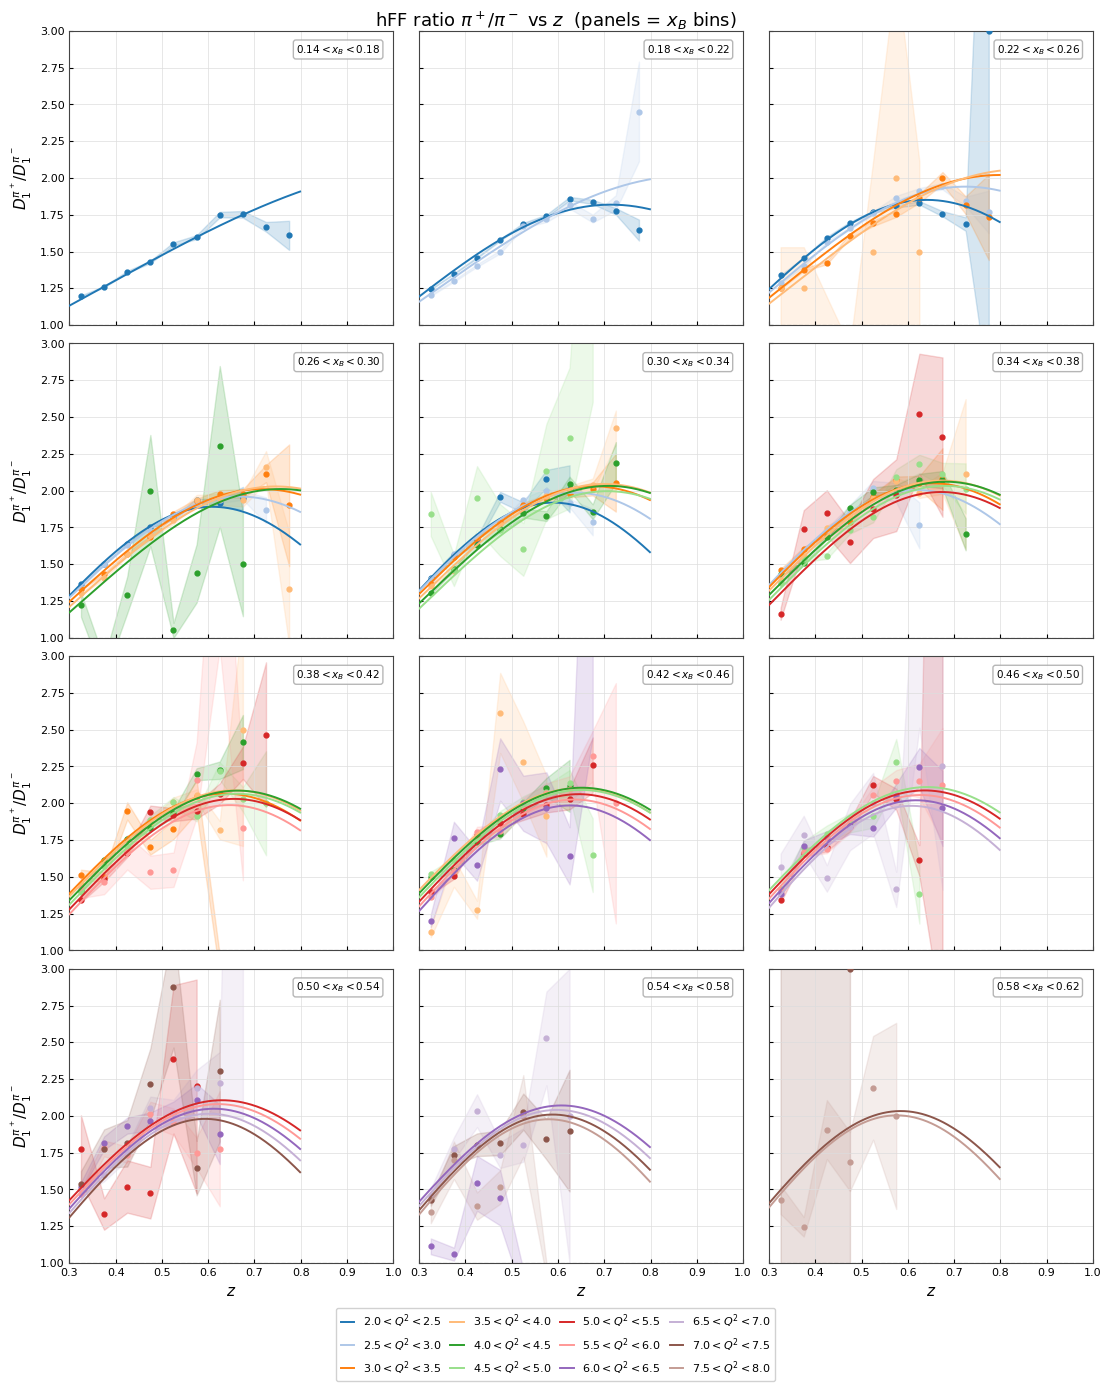

In [302]:
# ── hFF vs z  — panels = xB bins, colours = Q² bins ─────────────────────────

def plot_vs_z_xBpanels(vals, errs, pred, y_lim=Y_LIM):
    active_ix = [ix for ix in range(n_xB)
                 if any(np.isfinite(vals[ix, iq, :]).any() for iq in range(n_Q2))]
    n_active = len(active_ix)
    ncols    = 3
    nrows    = math.ceil(n_active / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(r'hFF ratio $\pi^+/\pi^-$ vs $z$  (panels = $x_B$ bins)', fontsize=13, y=1.01)
    axs_flat = np.array(axs).ravel()
    z_draw   = z_fine if Z_FIT_MAX is None else z_fine[z_fine < Z_FIT_MAX]

    for panel, ix in enumerate(active_ix):
        ax = axs_flat[panel]
        panel_label(ax, rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$')

        for iq in range(n_Q2):
            v, e = vals[ix, iq, :], errs[ix, iq, :]
            mask = np.isfinite(v) & np.isfinite(e)
            if not mask.any():
                continue
            c     = COLOR_LIST[iq % N_COLORS]
            label = rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$'
            ax.fill_between(z_centers[mask], (v-e)[mask], (v+e)[mask], color=c, alpha=0.18)
            ax.plot(z_centers[mask], v[mask], 'o', color=c, ms=3.5, zorder=3)
            x_fix = np.full_like(z_draw, xB_centers[ix])
            q_fix = np.full_like(z_draw, Q2_centers[iq])
            ax.plot(z_draw, pred(z_draw, x_fix, q_fix), color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(z_edges[0], z_edges[-1])
        ax.set_ylim(1,3)
        col = panel % ncols; row = panel // ncols
        if col == 0: ax.set_ylabel(r'$D_1^{\pi^+}/D_1^{\pi^-}$', fontsize=11)
        if row == nrows - 1: ax.set_xlabel(LABEL['z'], fontsize=11)

    for panel in range(n_active, nrows * ncols):
        axs_flat[panel].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:n_active]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 0.0),
               ncol=4, fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.2)
    return fig

fig = plot_vs_z_xBpanels(vals, errs, pred_FF)
plt.show()

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_53357/3758926019.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fit_pts.append(float(pred_FF(z_centers[iz], xB_centers[ix], Q2_centers[iq])))


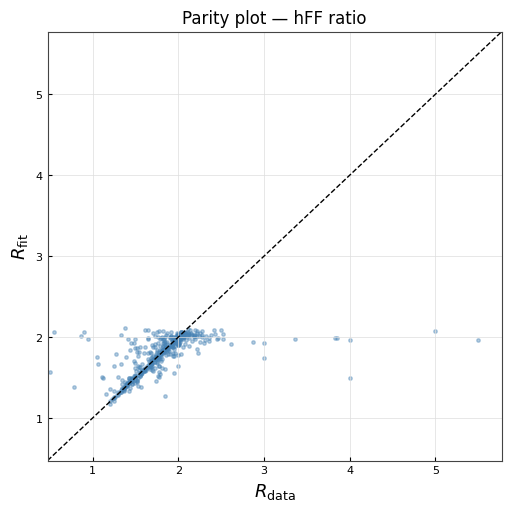

In [303]:
# ── Parity plot: data vs fit at bin centres ────────────────────────────────────

data_pts, fit_pts = [], []
for ix, iq, iz in iproduct(range(n_xB), range(n_Q2), range(n_z)):
    v, e = vals[ix, iq, iz], errs[ix, iq, iz]
    if not (np.isfinite(v) and np.isfinite(e) and v > 0):
        continue
    data_pts.append(v)
    fit_pts.append(float(pred_FF(z_centers[iz], xB_centers[ix], Q2_centers[iq])))

data_pts = np.array(data_pts)
fit_pts  = np.array(fit_pts)
lim      = (min(data_pts.min(), fit_pts.min()) * 0.95,
            max(data_pts.max(), fit_pts.max()) * 1.05)

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.scatter(data_pts, fit_pts, s=6, alpha=0.4, color='steelblue')
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(r'$R_{\rm data}$', fontsize=13)
ax.set_ylabel(r'$R_{\rm fit}$',  fontsize=13)
ax.set_title('Parity plot — hFF ratio', fontsize=12)
plt.show()

In [304]:
def plotDoU(x, Q2):
    s = np.log(np.log(np.asarray(Q2) / 0.030625) / np.log(0.26 / 0.030625))
    A = 0.6143 - 0.0065*s - 0.0040*s**2 + 0.0005*s**3
    B = 0.8940 - 0.1623*s + 0.0611*s**2 - 0.0107*s**3
    C = 0.0062 + 0.3772*s - 0.0881*s**2 + 0.0147*s**3
    return A * (1.0 - np.asarray(x))**B / (1.0 + C * np.sqrt(np.asarray(x)))

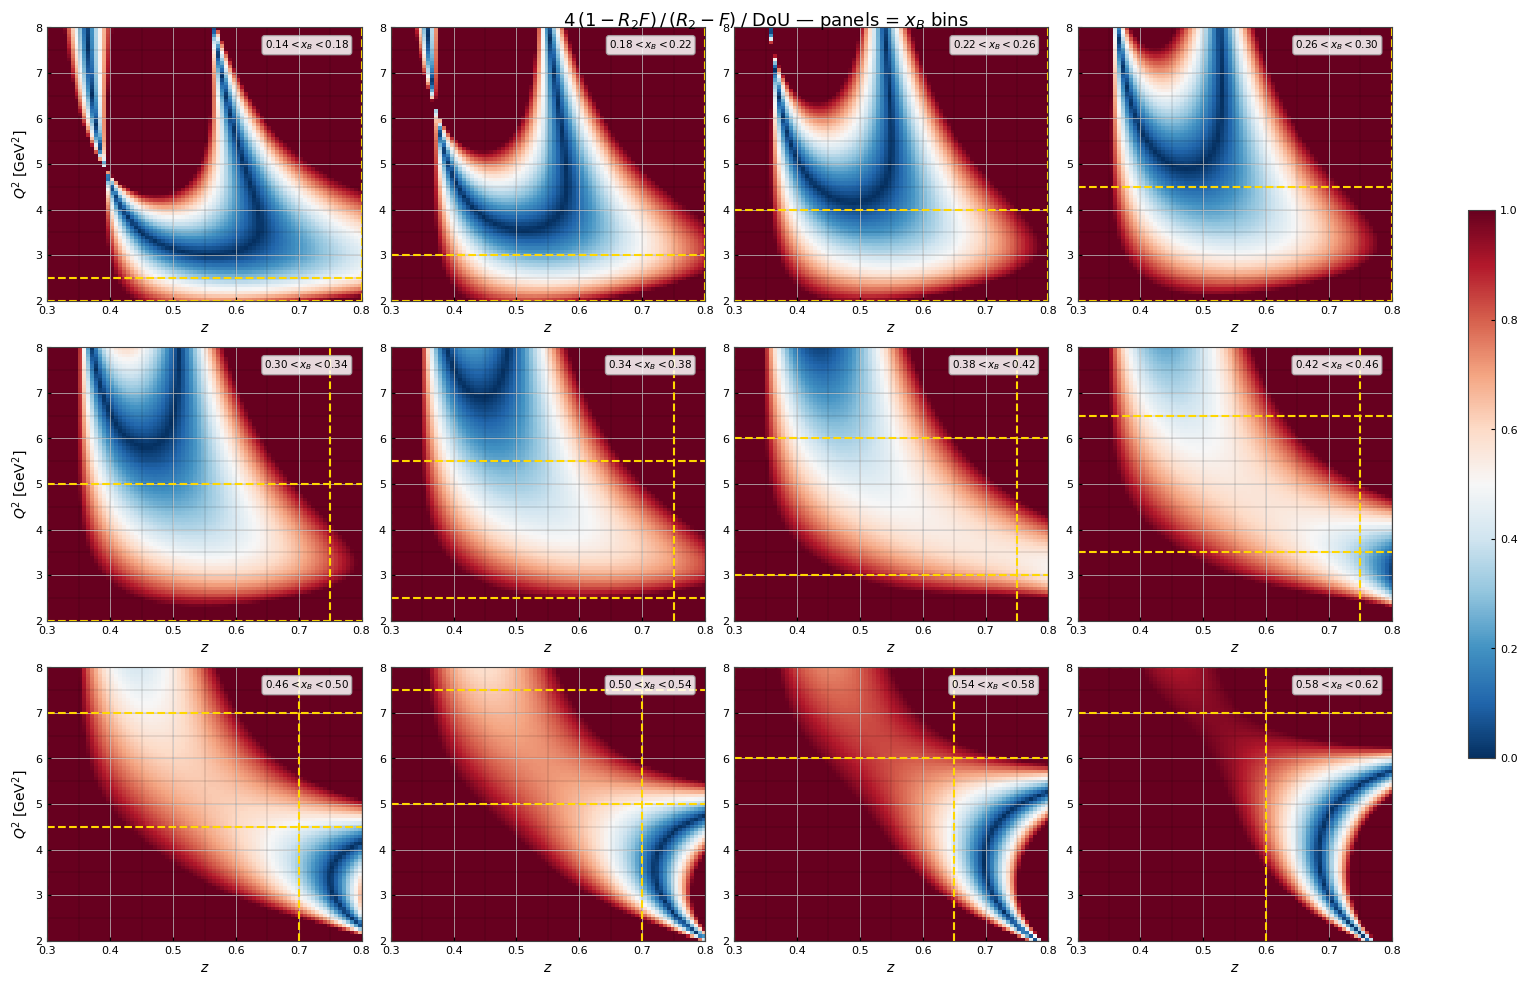

In [305]:
# ── Heatmap: combination of fit1 and fit2 in (Q², z) for each xB bin ──────────

Z_HM_MAX = 0.8

n_q_fine = 80
n_z_fine = 80
q2_fine  = np.linspace(Q2_edges[0], Q2_edges[-1], n_q_fine)
z_hm     = np.linspace(z_edges[0],  Z_HM_MAX,     n_z_fine)

active_ix = [ix for ix in range(n_xB)
             if any(np.isfinite(vals1[ix, iq, :]).any() for iq in range(n_Q2))]
n_active  = len(active_ix)
ncols     = 4
nrows     = math.ceil(n_active / ncols)

ZZ, QQ = np.meshgrid(z_hm, q2_fine)   # both (n_q_fine, n_z_fine)
grids   = []
for ix in active_ix:
    xB_fix = np.full(ZZ.size, xB_centers[ix])
    R1 = pred_FF1(ZZ.ravel(), xB_fix, QQ.ravel())
    R2 = pred_FF2(ZZ.ravel(), xB_fix, QQ.ravel())
    FF    = (4 - R1) / (4*R1 - 1)
    dOu   = 4.0 * (1 - R2*FF) / (R2 - FF)
    combo = (np.abs(dOu - plotDoU(xB_fix, QQ.ravel()))  / plotDoU(xB_fix, QQ.ravel())).reshape(n_q_fine, n_z_fine)
    grids.append(combo)

all_vals = np.concatenate([g.ravel() for g in grids])
vlim = np.nanpercentile(np.abs(all_vals), 98)
vmin, vmax = 0,1#-vlim, vlim

fig, axs = plt.subplots(nrows, ncols,
                         figsize=(3.8 * ncols, 3.2 * nrows),
                         constrained_layout=True)
fig.suptitle(r'$4\,(1 - R_2 F)\,/\,(R_2 - F)\;/\;\mathrm{DoU}$ — panels = $x_B$ bins',
             fontsize=13, y=1.01)
axs_flat = np.array(axs).ravel()

for panel, (ix, combo) in enumerate(zip(active_ix, grids)):
    ax = axs_flat[panel]
    im = ax.imshow(combo,
                   origin='lower', aspect='auto',
                   extent=[z_hm[0], Z_HM_MAX, q2_fine[0], q2_fine[-1]],
                   cmap='RdBu_r', vmin=vmin, vmax=vmax)
    panel_label(ax, rf'${xB_edges[ix]:.2f}<x_B<{xB_edges[ix+1]:.2f}$')

    # faint bin-edge grid
    for ze in z_edges[z_edges <= Z_HM_MAX]: ax.axvline(ze, color='k', lw=0.3, alpha=0.4)
    for qe in Q2_edges:                     ax.axhline(qe, color='k', lw=0.3, alpha=0.4)

    # filled-bin range lines in Q2 and z
    filled_iq = [iq for iq in range(n_Q2)
                 if np.isfinite(vals1[ix, iq, :]).any() or np.isfinite(vals2[ix, iq, :]).any()]
    filled_iz = [iz for iz in range(n_z)
                 if np.isfinite(vals1[ix, :, iz]).any() or np.isfinite(vals2[ix, :, iz]).any()]

    if filled_iq:
        q2_lo = Q2_edges[min(filled_iq)]
        q2_hi = Q2_edges[max(filled_iq) + 1]
        ax.axhline(q2_lo, color='gold', lw=1.5, ls='--')
        ax.axhline(q2_hi, color='gold', lw=1.5, ls='--')

    if filled_iz:
        z_lo = z_edges[min(filled_iz)]
        z_hi = min(z_edges[max(filled_iz) + 1], Z_HM_MAX)
        ax.axvline(z_lo, color='gold', lw=1.5, ls='--')
        ax.axvline(z_hi, color='gold', lw=1.5, ls='--')

    col = panel % ncols
    ax.set_xlabel(LABEL['z'],  fontsize=10)
    if col == 0: ax.set_ylabel(LABEL['Q2'], fontsize=10)

for panel in range(n_active, nrows * ncols):
    axs_flat[panel].set_visible(False)

fig.colorbar(im, ax=axs_flat[:n_active], shrink=0.6)
plt.show()


In [306]:
# ── Write combo panels to ROOT file as TH2Fs ─────────────────────────────────
import boost_histogram as bh

OUT_ROOT = '../data/corrections/dOu_heatmaps.root'

with uproot.recreate(OUT_ROOT) as fout:
    for ix, combo in zip(active_ix, grids):
        # TH2F axes: X = z, Y = Q²
        # combo shape is (n_q_fine, n_z_fine), so transpose to (n_z_fine, n_q_fine)
        h = bh.Histogram(
            bh.axis.Regular(n_z_fine, float(z_hm[0]),    float(Z_HM_MAX)),
            bh.axis.Regular(n_q_fine, float(q2_fine[0]), float(q2_fine[-1])),
        )
        h.view()[:] = combo.T
        fout[f'hCombo_ix{ix + 1}'] = h

print(f'Wrote {len(active_ix)} TH2Fs to {OUT_ROOT}')
print('Histogram names:', [f'hCombo_ix{ix+1}' for ix in active_ix])


Wrote 12 TH2Fs to ../data/corrections/dOu_heatmaps.root
Histogram names: ['hCombo_ix2', 'hCombo_ix3', 'hCombo_ix4', 'hCombo_ix5', 'hCombo_ix6', 'hCombo_ix7', 'hCombo_ix8', 'hCombo_ix9', 'hCombo_ix10', 'hCombo_ix11', 'hCombo_ix12', 'hCombo_ix13']
